---
title: "Question3: [Zero-Few Shot] DeepSeek-R1-Distill-Qwen-1.5B"
author: ["Guntas Singh Saran", "Prathmesh Maharshi"]
date: "2025-04-10"
image: "output.png"
format:
    html:
        code-fold: false
        code-tools: true
jupyter: python3
---

In [1]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.4/481.4 kB 30.1 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.29.0
    Uninstalling huggingface-hub-0.29.0:
      Successfully uninstalled huggingface-hub-0.29.0
  Attempting uninstall: transformers
    Found existing installation: transformers 4.47.0
    Uninstalling transformers-4.47.0:
      Successfully uninstalled transformers-4.47.0


In [2]:
from transformers import pipeline
import torch
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import pandas as pd
from datasets import load_dataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Load Dataset

In [4]:
ds = load_dataset("hpe-ai/medical-cases-classification-tutorial")
ds

README.md:   0%|          | 0.00/192 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


medical_cases_train.csv:   0%|          | 0.00/6.34M [00:00<?, ?B/s]

medical_cases_validation.csv:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

medical_cases_test.csv:   0%|          | 0.00/1.32M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1724 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/370 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/370 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['description', 'transcription', 'sample_name', 'medical_specialty', 'keywords'],
        num_rows: 1724
    })
    validation: Dataset({
        features: ['description', 'transcription', 'sample_name', 'medical_specialty', 'keywords'],
        num_rows: 370
    })
    test: Dataset({
        features: ['description', 'transcription', 'sample_name', 'medical_specialty', 'keywords'],
        num_rows: 370
    })
})

In [5]:
df = pd.DataFrame(ds["train"])
df

,description,transcription,sample_name,medical_specialty,keywords
0,Pacemaker ICD interrogation. Severe nonischem...,"PROCEDURE NOTE: , Pacemaker ICD interrogation....",Pacemaker Interrogation,Cardiovascular / Pulmonary,"cardiovascular / pulmonary, cardiomyopathy, ve..."
1,"Erythema of the right knee and leg, possible s...","PREOPERATIVE DIAGNOSES: , Erythema of the righ...",Aspiration - Knee Joint,Orthopedic,"orthopedic, knee and leg, anterolateral portal..."
2,Left cardiac catheterization with selective ri...,"PREOPERATIVE DIAGNOSIS: , Post infarct angina....",Cardiac Cath & Selective Coronary Angiography,Cardiovascular / Pulmonary,"cardiovascular / pulmonary, selective, angiogr..."
3,Patient with a history of coronary artery dise...,"REASON FOR VISIT: , Acute kidney failure.,HIST...",Acute Kidney Failure,Nephrology,None
4,Cardiac evaluation and treatment in a patient ...,"REASON FOR REFERRAL: , Cardiac evaluation and ...",Cardiac Consultation - 6,Cardiovascular / Pulmonary,None
...,...,...,...,...,...
1719,"Arthroscopy of the left knee, left arthroscopi...","PREOPERATIVE DIAGNOSIS:, Medial meniscal tear...","Arthroscopy, Meniscoplasty, & Chondroplasty",Orthopedic,"orthopedic, medial meniscoplasty, arthroscopic..."
1720,Normal awake and drowsy (stage I sleep) EEG fo...,"DESCRIPTION OF RECORD: ,This tracing was obta...",Electroencephalogram,Neurology,"neurology, gold-plated surface disc electrodes..."
1721,MRI of the brain without contrast to evaluate ...,"EXAM: , MRI of the brain without contrast.,HIS...",MRI of Brain w/o Contrast.,Neurology,"neurology, mri, diffusion, posterior fossa, ax..."
1722,The patient comes for three-week postpartum ch...,"CHIEF COMPLAINT:, The patient comes for three...",Three-Week Postpartum Checkup,Obstetrics / Gynecology,"obstetrics / gynecology, checkup, allergies, p..."


# Get the Unique Classes of `medical_speciality`

In [6]:
cls = [df.loc[i, "medical_specialty"] for i in range(len(df))]
classes = list(set(cls))
classes, len(classes)

(['ENT - Otolaryngology',
  'Ophthalmology',
  'Hematology - Oncology',
  'Pediatrics - Neonatal',
  'Radiology',
  'Neurosurgery',
  'Orthopedic',
  'Obstetrics / Gynecology',
  'Psychiatry / Psychology',
  'Cardiovascular / Pulmonary',
  'Gastroenterology',
  'Nephrology',
  'Neurology'],
 13)

# Load the Model using `huggingface` `pipeline`

In [ ]:
!huggingface-cli login --token <TOKEN>

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
The token `llm` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `llm`


In [8]:
model = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
classifier = pipeline("text-generation", model=model)

config.json:   0%|          | 0.00/679 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.55G [00:00<?, ?B/s]

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Device set to use cuda:0


In [9]:
cls_str = ", ".join(classes)
cls_str

'ENT - Otolaryngology, Ophthalmology, Hematology - Oncology, Pediatrics - Neonatal, Radiology, Neurosurgery, Orthopedic, Obstetrics / Gynecology, Psychiatry / Psychology, Cardiovascular / Pulmonary, Gastroenterology, Nephrology, Neurology'

# Zero-Shot Prompt Template

In [10]:
prompt_template = """
You are a medical expert tasked with classifying a disease description into one of these medical specialties: {cls_str}. Analyze the description carefully, focusing on symptoms, conditions, and medical terms. Select the most appropriate specialty from the list and output ONLY the specialty name inside brackets, like [Specialty Name]. Do not repeat the prompt or add extra text—just the prediction in this format: [Specialty Name].

Description: {description}

Predicted Medical Specialty: 
"""

# Demo of the workflow ahead

In [11]:
dscrp = df.loc[285, "description"]
tr_cls = df.loc[285, "medical_specialty"]
print(tr_cls)
print("="*50)
prompt = prompt_template.format(cls_str=cls_str, description=dscrp)
result = classifier(prompt, max_new_tokens=20, do_sample=False)[0]['generated_text']
print(result)
generated_text = result[len(prompt):].strip()
pred_specialty = generated_text.split("[")[1].split("]")[0].strip()
print("="*50)
print(pred_specialty)

Cardiovascular / Pulmonary


/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.95` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(



You are a medical expert tasked with classifying a disease description into one of these medical specialties: ENT - Otolaryngology, Ophthalmology, Hematology - Oncology, Pediatrics - Neonatal, Radiology, Neurosurgery, Orthopedic, Obstetrics / Gynecology, Psychiatry / Psychology, Cardiovascular / Pulmonary, Gastroenterology, Nephrology, Neurology. Analyze the description carefully, focusing on symptoms, conditions, and medical terms. Select the most appropriate specialty from the list and output ONLY the specialty name inside brackets, like [Specialty Name]. Do not repeat the prompt or add extra text—just the prediction in this format: [Specialty Name].

Description: Problem of essential hypertension.  Symptoms that suggested intracranial pathology.

Predicted Medical Specialty: 
</think>

[Neurology]
Neurology


# Classical Way: Slow

In [12]:
# df = pd.DataFrame(ds["test"])

In [13]:
# true_labels = []
# pred_labels = []

# for index, row in tqdm(df.iterrows()):
#     description = row["description"]
#     true_label = row["medical_specialty"]
#     true_labels.append(true_label)
    
#     prompt = prompt_template.format(cls_str=cls_str, description=description)
#     result = classifier(prompt, max_new_tokens=10, do_sample=False)[0]['generated_text']
#     generated_text = result[len(prompt):].strip()
#     pred_specialty = generated_text.split("[")[1].split("]")[0].strip() if "[" in generated_text else generated_text
#     pred_labels.append(pred_specialty)

In [14]:
# precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average="weighted", zero_division=0)
# conf_matrix = confusion_matrix(true_labels, pred_labels, labels=classes)

# print(f"\nFew-Shot Learning Metrics ({num_shots} Shots):")
# print(f"Precision: {precision:.3f}")
# print(f"Recall: {recall:.3f}")
# print(f"F1 Score: {f1:.3f}")
# print("Confusion Matrix:")
# print(conf_matrix)

# Optimised Way: Applying Maps over `datasets`

In [15]:
classifier = pipeline("text-generation", model=model, device=0, batch_size=16)

Device set to use cuda:0


In [16]:
dataset = ds["test"]

In [17]:
def format_prompts(example):
    example["prompt"] = prompt_template.format(cls_str=cls_str, description=example["description"])
    example["true_label"] = example["medical_specialty"]
    return example

dataset = dataset.map(format_prompts)

Map:   0%|          | 0/370 [00:00<?, ? examples/s]

In [18]:
def predict_batch(examples):
    prompts = examples["prompt"]
    results = classifier(prompts, max_new_tokens=10, do_sample=False)
    predictions = [result[0]["generated_text"][len(prompt):].strip() for prompt, result in zip(prompts, results)]
    examples["prediction"] = [pred.split("[")[1].split("]")[0].strip() if "[" in pred else pred for pred in predictions]
    return examples

dataset = dataset.map(predict_batch, batched=True, batch_size=16)

Map:   0%|          | 0/370 [00:00<?, ? examples/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Zero-Shot Learning Metrics:
Precision: 0.192
Recall: 0.146
F1 Score: 0.097
Confusion Matrix:


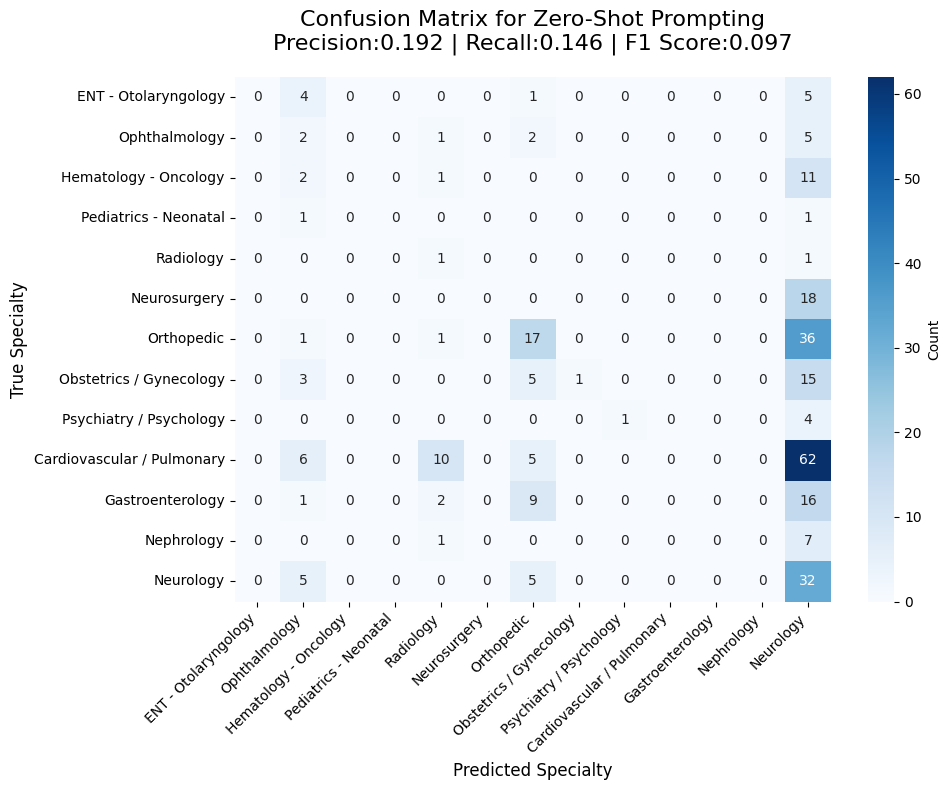

In [19]:
df_results = dataset.to_pandas()

true_labels = df_results["true_label"].tolist()
pred_labels = df_results["prediction"].tolist()

precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average="weighted", zero_division=0)
conf_matrix = confusion_matrix(true_labels, pred_labels, labels=classes)

print("Zero-Shot Learning Metrics:")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print("Confusion Matrix:")
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=classes, yticklabels=classes, 
            cbar_kws={'label': 'Count'})
plt.title(f"Confusion Matrix for Zero-Shot Prompting\nPrecision:{precision:.3f} | Recall:{recall:.3f} | F1 Score:{f1:.3f}", fontsize=16, pad=20)
plt.xlabel("Predicted Specialty", fontsize=12)
plt.ylabel("True Specialty", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
for tr, pr in zip(true_labels, pred_labels):
    print((tr, pr))

('Orthopedic', 'Neurology')
('Cardiovascular / Pulmonary', 'Ophthalmology')
('Cardiovascular / Pulmonary', 'ENT')
('Orthopedic', 'Neurology')
('Neurology', 'Ophthalmology')
('ENT - Otolaryngology', 'ENT')
('Neurology', 'Neurology')
('Gastroenterology', 'Neurology')
('Cardiovascular / Pulmonary', 'Neurology')
('Gastroenterology', 'Entertainment')
('Obstetrics / Gynecology', 'Orthopedic')
('Cardiovascular / Pulmonary', 'Neurology')
('Cardiovascular / Pulmonary', 'Neurology')
('Orthopedic', 'Neurology')
('Cardiovascular / Pulmonary', 'Neurology')
('Neurology', 'Neurology')
('Obstetrics / Gynecology', 'Neonatal Neonoscience')
('Cardiovascular / Pulmonary', 'Neurology')
('Neurology', 'Ophthalmology')
('Neurosurgery', 'Neurology')
('Orthopedic', 'Neurology')
('Cardiovascular / Pulmonary', 'ENT')
('Cardiovascular / Pulmonary', 'Hematology')
('Obstetrics / Gynecology', 'Neurology')
('Ophthalmology', 'Ophthalmology')
('Cardiovascular / Pulmonary', 'ENT')
('Orthopedic', 'Neurology')
('Hematology

# Few-Shot Prompting

In [21]:
few_shot_template = """
You are a medical expert classifying clinical descriptions into one of the following medical specialties: {cls_str}.

Each example contains a medical case description and its correct specialty. Think internally about symptoms, keywords, and related conditions, then output the specialty that best matches.

IMPORTANT:
- DO NOT WRITE WHAT YOU THINK
- But you must only output the final specialty, in this exact format: [Specialty Name]
- Do not explain your reasoning.
- Do not say if you're unsure. If you're unsure just give any of the listed specialities in the stated format.
- Do not use placeholders or extra text.

Examples:
{examples}

New Description: {description}

Predicted Medical Specialty:
"""


In [22]:
dataset_train = ds["train"]
dataset_test = ds["test"]

# Generate Random Examples of a superset of Unique Labels atleast

In [23]:
def create_random_examples(dataset, num_shots):
    # indices = np.random.choice(len(dataset), min(num_shots, len(dataset)), replace=False)
    # examples = ""
    # for i, idx in enumerate(indices, 1):
    #     row = dataset[int(idx)]
    #     examples += f"{i}. Description: {row['description']}\n   Medical Specialty: {row['medical_specialty']}\n"
    # return examples
    df = pd.DataFrame(dataset)
    unique_labels = df["medical_specialty"].unique()
    num_unique = len(unique_labels)
    
    selected_indices = []
    for label in unique_labels:
        if len(selected_indices) >= num_shots:
            break
        label_indices = df[df["medical_specialty"] == label].index.tolist()
        selected_indices.append(np.random.choice(label_indices))
    
    if num_shots > num_unique:
        remaining = num_shots - num_unique
        additional_indices = np.random.choice(len(dataset), remaining, replace=True)
        selected_indices.extend(additional_indices)
    
    selected_indices = selected_indices[:num_shots]
    
    examples = ""
    for i, idx in enumerate(selected_indices, 1):
        row = dataset[int(idx)]
        examples += f"{i}. Description:\n{row['description']}\nMedical Specialty:\n[{row['medical_specialty']}]\n\n"
    return examples

# Example Workflow

In [24]:
num_shots = 10
exs = create_random_examples(dataset_train, num_shots)
print(exs)

1. Description:
CCTA with cardiac function and calcium scoring.
Medical Specialty:
[Cardiovascular / Pulmonary]

2. Description:
Acetabular fracture on the left posterior column/transverse posterior wall variety with an accompanying displaced fracture of the intertrochanteric variety to the left hip.  Osteosynthesis of acetabular fracture on the left, complex variety and total hip replacement.
Medical Specialty:
[Orthopedic]

3. Description:
Acute renal failure, suspected, likely due to multi-organ system failure syndrome.
Medical Specialty:
[Nephrology]

4. Description:
Excision of left breast mass.  The mass was identified adjacent to the left nipple.  It was freely mobile and it did not seem to hold the skin.
Medical Specialty:
[Obstetrics / Gynecology]

5. Description:
Pars plana vitrectomy, membrane peel, 23-gauge, right eye.
Medical Specialty:
[Ophthalmology]

6. Description:
Patient with history of polyps.
Medical Specialty:
[Gastroenterology]

7. Description:
A woman presents f

In [25]:
df_test = pd.DataFrame(dataset_test)
dscrp = df_test.loc[250, "description"]
tr_cls = df_test.loc[250, "medical_specialty"]
print(tr_cls)
print("="*50)
prompt = few_shot_template.format(num_shots=num_shots, cls_str=cls_str, examples=exs, description=dscrp)
result = classifier(prompt, max_new_tokens=10, do_sample=False)[0]['generated_text']
print(result)
intermed_result = result[len(prompt):]
generated_text = intermed_result.strip().split("\n")[0] if "\n" in intermed_result else intermed_result.strip()
pred_specialty = generated_text.split("[")[1].split("]")[0].strip() if "[" in generated_text else generated_text
print("="*50)
print(pred_specialty)

Cardiovascular / Pulmonary


/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.95` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(



You are a medical expert classifying clinical descriptions into one of the following medical specialties: ENT - Otolaryngology, Ophthalmology, Hematology - Oncology, Pediatrics - Neonatal, Radiology, Neurosurgery, Orthopedic, Obstetrics / Gynecology, Psychiatry / Psychology, Cardiovascular / Pulmonary, Gastroenterology, Nephrology, Neurology.

Each example contains a medical case description and its correct specialty. Think internally about symptoms, keywords, and related conditions, then output the specialty that best matches.

IMPORTANT:
- DO NOT WRITE WHAT YOU THINK
- But you must only output the final specialty, in this exact format: [Specialty Name]
- Do not explain your reasoning.
- Do not say if you're unsure. If you're unsure just give any of the listed specialities in the stated format.
- Do not use placeholders or extra text.

Examples:
1. Description:
CCTA with cardiac function and calcium scoring.
Medical Specialty:
[Cardiovascular / Pulmonary]

2. Description:
Acetabular 

In [26]:
def format_few_shot_prompts(examples_str, num_shots):
    def _format(example):
        example["prompt"] = few_shot_template.format(num_shots=num_shots, cls_str=cls_str, examples=examples_str, description=example["description"])
        example["true_label"] = example["medical_specialty"]
        return example
    return _format

In [27]:
def predict_batch(examples):
    prompts = examples["prompt"]
    results = classifier(prompts, max_new_tokens=10, do_sample=False)
    predictions = [result[0]["generated_text"][len(prompt):].strip().split("\n")[0] if "\n" in result[0]["generated_text"][len(prompt):] else result[0]["generated_text"][len(prompt):].strip() for prompt, result in zip(prompts, results)]
    examples["prediction"] = [pred.split("[")[1].split("]")[0].strip() if "[" in pred else pred for pred in predictions]
    return examples

Map:   0%|          | 0/370 [00:00<?, ? examples/s]

Map:   0%|          | 0/370 [00:00<?, ? examples/s]


Few-Shot Learning Metrics (15 Shots):
Precision: 0.418
Recall: 0.154
F1 Score: 0.114
Confusion Matrix:
[[ 0  5  0  0  0  0  0  0  0  0  0  0  9]
 [ 0  2  0  0  0  0  0  0  0  0  0  0  8]
 [ 0  0  0  0  0  0  0  2  0  0  0  0  7]
 [ 0  0  0  2  0  0  0  0  0  0  0  0  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 0  0  0  1  0  1  2  2  0  0  0  0 13]
 [ 0  0  0  0  0  2  1  7  0  0  0  0 43]
 [ 0  2  0  2  0  0  0  7  0  0  0  0 18]
 [ 0  0  0  0  0  0  0  3  5  0  0  0  1]
 [ 0  2  0 10  0  0  0  3  0  7  0  0 76]
 [ 0  9  0  3  0  0  0  8  0  0  0  0 14]
 [ 0  0  0  1  0  0  0  0  1  0  0  0  6]
 [ 0  1  0  2  0  1  0  3  0  0  0  0 32]]


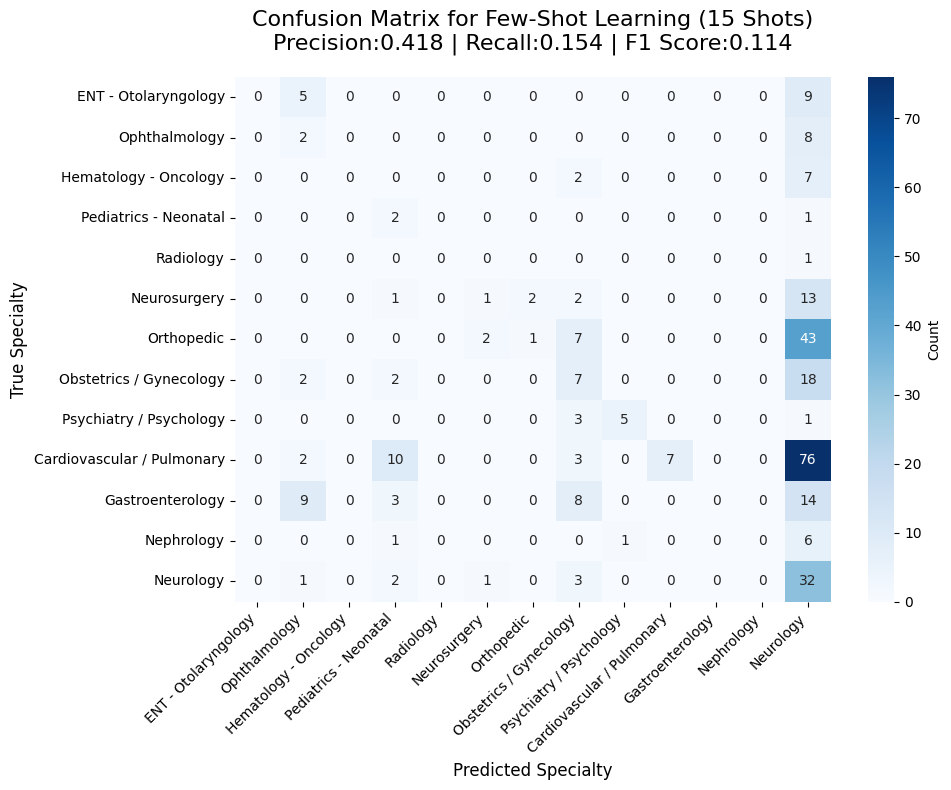

In [28]:
# shot_counts = [10, 15, 20]
num_shots = 15

# for num_shots in shot_counts:
# provide train dataset examples for few-shot
examples_str = create_random_examples(dataset_train, num_shots)

# infer on the test dataset
formatted_dataset = dataset_test.map(format_few_shot_prompts(examples_str, num_shots))

formatted_dataset = formatted_dataset.map(predict_batch, batched=True, batch_size=16)

df_results = formatted_dataset.to_pandas()

true_labels = df_results["true_label"].tolist()
pred_labels = df_results["prediction"].tolist()

precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average="weighted", zero_division=0)
conf_matrix = confusion_matrix(true_labels, pred_labels, labels=classes)

print(f"\nFew-Shot Learning Metrics ({num_shots} Shots):")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print("Confusion Matrix:")
print(conf_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=classes, yticklabels=classes, 
            cbar_kws={'label': 'Count'})
plt.title(f"Confusion Matrix for Few-Shot Learning ({num_shots} Shots)\nPrecision:{precision:.3f} | Recall:{recall:.3f} | F1 Score:{f1:.3f}", fontsize=16, pad=20)
plt.xlabel("Predicted Specialty", fontsize=12)
plt.ylabel("True Specialty", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
torch.cuda.synchronize()

In [30]:
torch.cuda.empty_cache()

In [31]:
for tr, pr in zip(true_labels, pred_labels):
    print((tr, pr))

('Orthopedic', 'Neurology')
('Cardiovascular / Pulmonary', 'Neurology')
('Cardiovascular / Pulmonary', 'Pediatric - Neonatal')
('Orthopedic', 'Neurology')
('Neurology', 'Neurology')
('ENT - Otolaryngology', 'Neurology')
('Neurology', 'Neurology')
('Gastroenterology', 'Pediatric - Neonatal')
('Cardiovascular / Pulmonary', 'Neurology')
('Gastroenterology', 'Specialty Name')
('Obstetrics / Gynecology', 'Ophthalmology')
('Cardiovascular / Pulmonary', 'Neurology')
('Cardiovascular / Pulmonary', 'Neurology')
('Orthopedic', 'Neurology')
('Cardiovascular / Pulmonary', 'Neurology')
('Neurology', 'Specialty Name')
('Obstetrics / Gynecology', 'Neurology')
('Cardiovascular / Pulmonary', 'Neurology')
('Neurology', 'Neurology')
('Neurosurgery', 'Specialty Name')
('Orthopedic', 'Neurology')
('Cardiovascular / Pulmonary', 'Neurology')
('Cardiovascular / Pulmonary', 'Neurology')
('Obstetrics / Gynecology', 'Neurology')
('Ophthalmology', 'Ophthalmology')
('Cardiovascular / Pulmonary', 'Neurology')
('Ort